In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Load features and labels
cnv_df = pd.read_csv("cnvs_cleaned_SXT.csv", index_col=0)
profiles = pd.read_csv("SXT_profile.csv", index_col=0)
features = pd.read_csv("features_cnv.csv", index_col=0)

In [52]:
# Find common samples between CNV data and resistance profile data and keep only common samples
# Start by removing duplicate entries
profiles = profiles.loc[~profiles.index.duplicated(keep='first')]
cnv_df = cnv_df.loc[~cnv_df.index.duplicated(keep='first')]

# Find common samples
common_samples = cnv_df.index.intersection(profiles.index)

# Keep only samples with both CNV and phenotype data
cnv_df = cnv_df.loc[common_samples]
profiles = profiles.loc[common_samples]
cnv_df = pd.concat([cnv_df, profiles], axis=1)

print(f"\nMerged data shape:")
print(f"CNVs: {cnv_df.shape}")
print(f"Resistance profiles: {profiles.shape}")


Merged data shape:
CNVs: (221, 7198)
Resistance profiles: (221, 1)


In [59]:
features.index

Index(['cnv_depth__IBNLCO_05717__mipA__gene__promoter',
       'cnv_depth__IBNLCO_00393__IBNLCO_00393__gene',
       'cnv_depth__IBNLCO_05223__IBNLCO_05223__gene__promoter',
       'cnv_depth__IBNLCO_03972__Succinyl-CoA:coenzyme__CDS__promoter',
       'cnv_depth__IBNLCO_00442__IBNLCO_00442__gene__promoter',
       'cnv_depth__IBNLCO_04983__Type__CDS__promoter',
       'cnv_depth__IBNLCO_05777__Ferredoxin--NAD(+)__CDS__promoter',
       'cnv_depth__IBNLCO_04222__IBNLCO_04222__gene',
       'cnv_depth__IBNLCO_04972__N-acetylmuramoyl-L-alanine__CDS__promoter',
       'cnv_depth__IBNLCO_04703__IBNLCO_04703__gene__promoter',
       ...
       'cnv_depth__IBNLCO_02036__DUF4123__CDS__promoter',
       'cnv_depth__IBNLCO_02035__IBNLCO_02035__gene',
       'cnv_depth__IBNLCO_02035__IBNLCO_02035__gene__promoter',
       'cnv_depth__IBNLCO_02034__Inclusion__CDS',
       'cnv_depth__IBNLCO_02034__Inclusion__CDS__promoter',
       'cnv_depth__IBNLCO_02031__IBNLCO_02031__gene__promoter',
       'cn

In [83]:
foi = features.head(29).index.tolist() + ["SXT"] + ["cnv_depth__IBNLCO_05817__mlaC__gene__promoter"]
foi

['cnv_depth__IBNLCO_05717__mipA__gene__promoter',
 'cnv_depth__IBNLCO_00393__IBNLCO_00393__gene',
 'cnv_depth__IBNLCO_05223__IBNLCO_05223__gene__promoter',
 'cnv_depth__IBNLCO_03972__Succinyl-CoA:coenzyme__CDS__promoter',
 'cnv_depth__IBNLCO_00442__IBNLCO_00442__gene__promoter',
 'cnv_depth__IBNLCO_04983__Type__CDS__promoter',
 'cnv_depth__IBNLCO_05777__Ferredoxin--NAD(+)__CDS__promoter',
 'cnv_depth__IBNLCO_04222__IBNLCO_04222__gene',
 'cnv_depth__IBNLCO_04972__N-acetylmuramoyl-L-alanine__CDS__promoter',
 'cnv_depth__IBNLCO_04703__IBNLCO_04703__gene__promoter',
 'cnv_depth__IBNLCO_00341__IBNLCO_00341__gene',
 'cnv_depth__IBNLCO_05722__IBNLCO_05722__gene',
 'cnv_depth__IBNLCO_04550__IBNLCO_04550__gene',
 'cnv_depth__IBNLCO_04459__IBNLCO_04459__gene__promoter',
 'cnv_depth__IBNLCO_04172__hypothetical__CDS__promoter',
 'cnv_depth__IBNLCO_02985__Signal__CDS__promoter',
 'cnv_depth__IBNLCO_04115__hypothetical__CDS',
 'cnv_depth__IBNLCO_04378__IBNLCO_04378__gene__promoter',
 'cnv_depth__IBN

In [84]:
cnv_foi = cnv_df[foi]
cnv_foi.columns

Index(['cnv_depth__IBNLCO_05717__mipA__gene__promoter',
       'cnv_depth__IBNLCO_00393__IBNLCO_00393__gene',
       'cnv_depth__IBNLCO_05223__IBNLCO_05223__gene__promoter',
       'cnv_depth__IBNLCO_03972__Succinyl-CoA:coenzyme__CDS__promoter',
       'cnv_depth__IBNLCO_00442__IBNLCO_00442__gene__promoter',
       'cnv_depth__IBNLCO_04983__Type__CDS__promoter',
       'cnv_depth__IBNLCO_05777__Ferredoxin--NAD(+)__CDS__promoter',
       'cnv_depth__IBNLCO_04222__IBNLCO_04222__gene',
       'cnv_depth__IBNLCO_04972__N-acetylmuramoyl-L-alanine__CDS__promoter',
       'cnv_depth__IBNLCO_04703__IBNLCO_04703__gene__promoter',
       'cnv_depth__IBNLCO_00341__IBNLCO_00341__gene',
       'cnv_depth__IBNLCO_05722__IBNLCO_05722__gene',
       'cnv_depth__IBNLCO_04550__IBNLCO_04550__gene',
       'cnv_depth__IBNLCO_04459__IBNLCO_04459__gene__promoter',
       'cnv_depth__IBNLCO_04172__hypothetical__CDS__promoter',
       'cnv_depth__IBNLCO_02985__Signal__CDS__promoter',
       'cnv_depth__IBNLCO

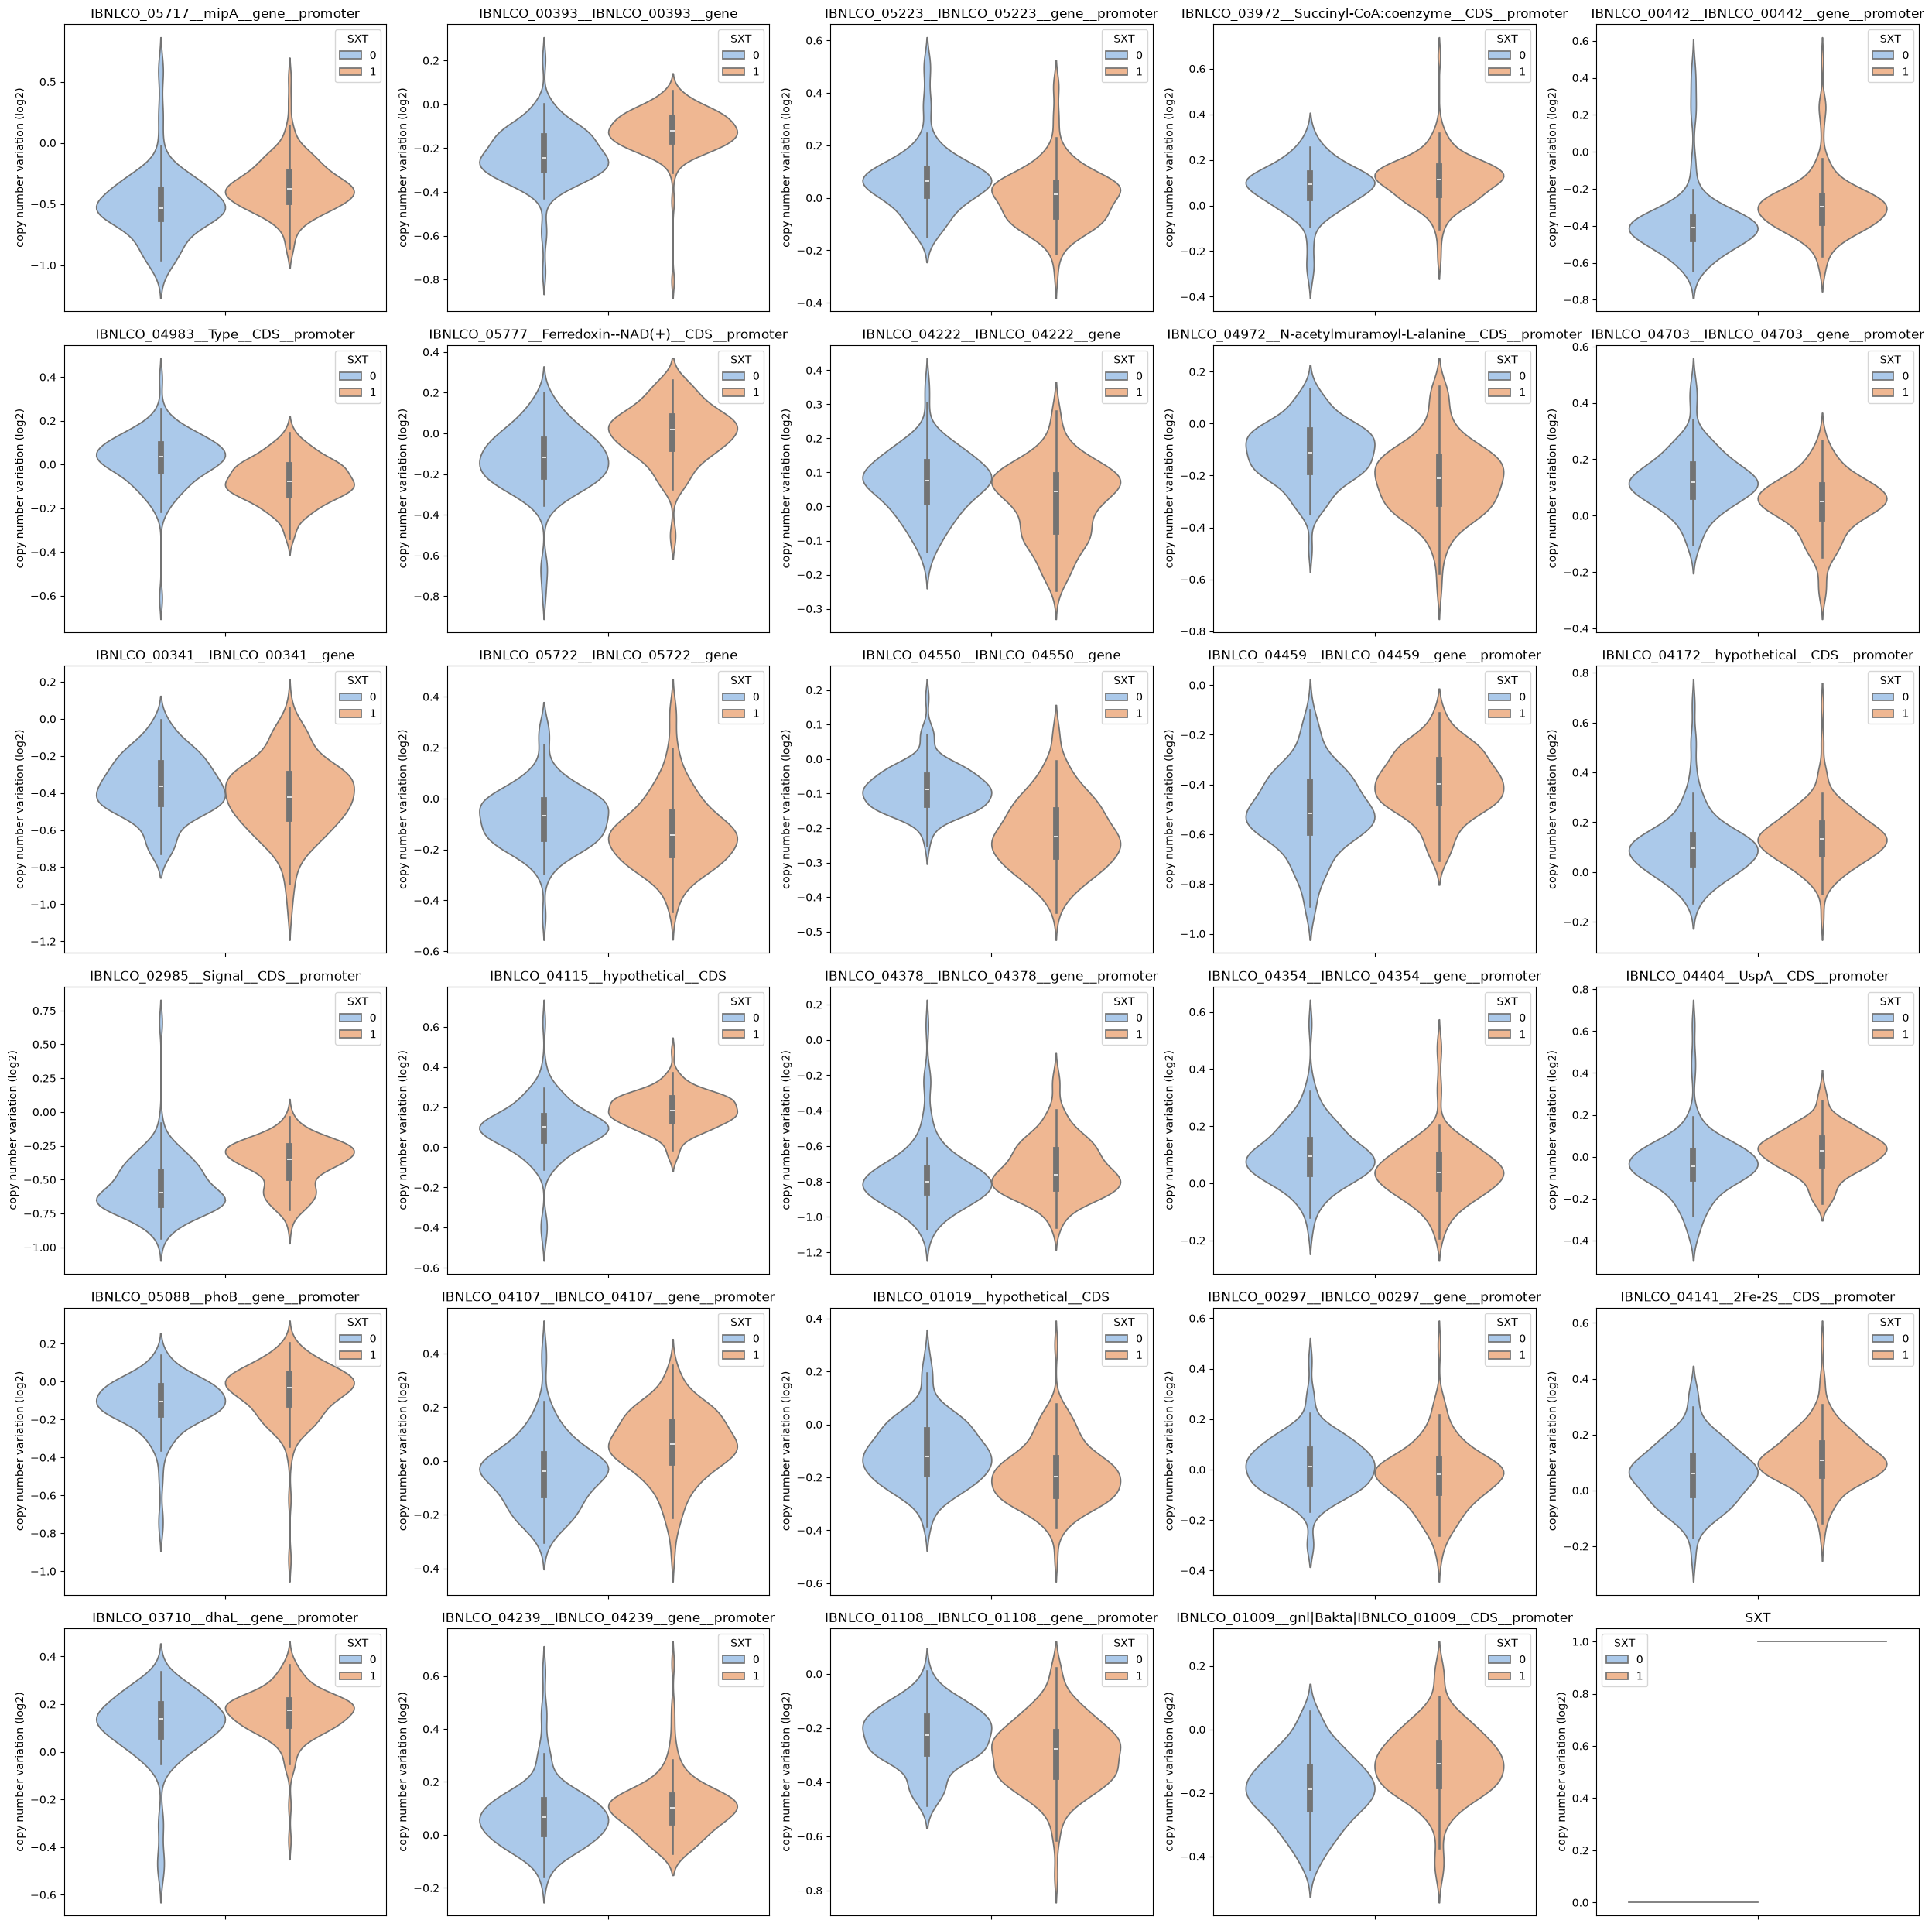

In [85]:
fig, axes = plt.subplots(6, 5, figsize=(25, 25))
axes = axes.flatten()

for ax, feature in zip(axes, foi):
    sns.violinplot(data=cnv_foi, hue="SXT", y=feature, ax=ax, palette="pastel")
    ax.set_title(feature.replace("cnv_depth__", ""))
    ax.set_ylabel("copy number variation (log2)")

plt.tight_layout()
plt.show()